In [842]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import jarque_bera,norm
from statsmodels.formula.api import ols

In [858]:

data = yf.download("CL=F",start='2021-01-01')





[*********************100%***********************]  1 of 1 completed


In [859]:

data.columns = [ d[0] for d in data.columns]



In [860]:
data['returns'] = ( data['Close']- data['Close'].shift(1) ) /  data['Close'].shift(1) *100

In [861]:
data.dropna(inplace=True)
data.reset_index(inplace=True)

In [862]:
data['weekdays'] =data['Date'].dt.day_name()

In [863]:
data

,Date,Close,High,Low,Open,Volume,returns,weekdays
0,2021-01-05,49.930000,50.200001,47.240002,47.380001,643191,4.850906,Tuesday
1,2021-01-06,50.630001,50.939999,49.480000,49.820000,509365,1.401964,Wednesday
2,2021-01-07,50.830002,51.279999,50.389999,50.529999,369292,0.395024,Thursday
3,2021-01-08,52.240002,52.750000,50.810001,50.930000,499416,2.773952,Friday
4,2021-01-11,52.250000,52.700001,51.500000,52.580002,394822,0.019139,Monday
...,...,...,...,...,...,...,...,...
1422,2026-09-01,90.220001,90.970001,86.129997,86.309998,331106,5.200559,Tuesday
1423,2026-09-02,91.010002,92.290001,88.970001,90.650002,283450,0.875638,Wednesday
1424,2026-09-03,91.300003,93.139999,89.570000,90.699997,324521,0.318647,Thursday
1425,2026-09-04,91.480003,92.169998,88.720001,91.669998,324521,0.197153,Friday


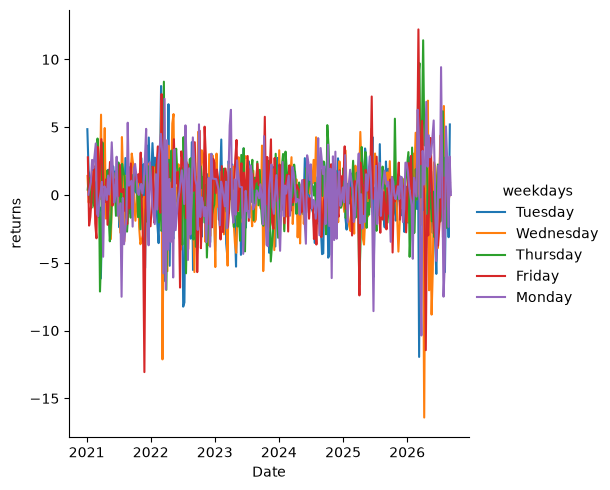

In [864]:
sns.relplot(data,x="Date",y='returns',kind='line',hue='weekdays')

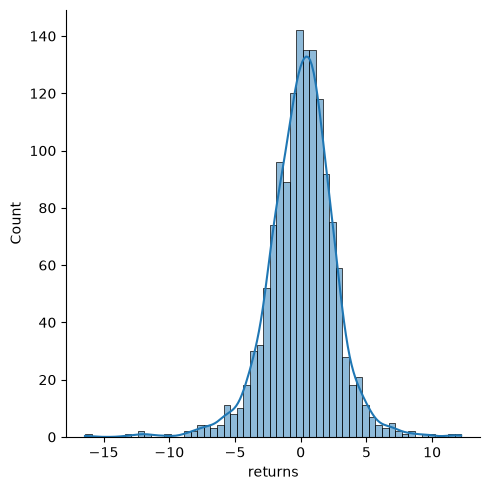

In [865]:
sns.displot(data,x='returns',kde=True)

In [866]:
jarque_bera(data['returns'])

SignificanceResult(statistic=np.float64(917.4986710658012), pvalue=np.float64(5.857266726829865e-200))

In [867]:
data.groupby('weekdays')['returns'].agg(['mean','median'])

,mean,median
weekdays,,
Friday,0.174870,0.293621
Monday,0.178906,0.320046
Thursday,0.204395,0.245364
Tuesday,-0.132307,0.000000
Wednesday,-0.018800,0.197935


In [868]:
data['months'] =data['Date'].dt.month

In [869]:
data.groupby('months')['returns'].agg(['mean','median'])

,mean,median
months,,
1,0.374970,0.477395
2,0.228593,0.410805
3,0.443856,0.360416
4,0.012869,0.321740
5,-0.120373,-0.014018
6,-0.005527,0.302342
7,0.266928,0.222899
8,-0.183841,-0.156735
9,0.035083,0.072790


In [870]:
adfuller(data['returns'])

(np.float64(-8.95221709189069),
 np.float64(8.662139107734527e-15),
 15,
 1411,
 {'1%': np.float64(-3.434992974078597),
  '5%': np.float64(-2.863590546293418),
  '10%': np.float64(-2.567861701478863)},
 np.float64(6592.730124796442))

In [871]:
kpss(data['returns'])

C:\Users\Bullet\AppData\Local\Temp\ipykernel_7380\4084071945.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss(data['returns'])


(np.float64(0.11077213102873437),
 np.float64(0.1),
 4,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [872]:
data['dif_lag_1'] = data['Close'] - data['Close'].shift(1)

In [873]:
data.dropna(inplace=True)

In [874]:
data

,Date,Close,High,Low,Open,Volume,returns,weekdays,months,dif_lag_1
1,2021-01-06,50.630001,50.939999,49.480000,49.820000,509365,1.401964,Wednesday,1,0.700001
2,2021-01-07,50.830002,51.279999,50.389999,50.529999,369292,0.395024,Thursday,1,0.200001
3,2021-01-08,52.240002,52.750000,50.810001,50.930000,499416,2.773952,Friday,1,1.410000
4,2021-01-11,52.250000,52.700001,51.500000,52.580002,394822,0.019139,Monday,1,0.009998
5,2021-01-12,53.209999,53.450001,52.070000,52.180000,400200,1.837319,Tuesday,1,0.959999
...,...,...,...,...,...,...,...,...,...,...
1422,2026-09-01,90.220001,90.970001,86.129997,86.309998,331106,5.200559,Tuesday,9,4.459999
1423,2026-09-02,91.010002,92.290001,88.970001,90.650002,283450,0.875638,Wednesday,9,0.790001
1424,2026-09-03,91.300003,93.139999,89.570000,90.699997,324521,0.318647,Thursday,9,0.290001
1425,2026-09-04,91.480003,92.169998,88.720001,91.669998,324521,0.197153,Friday,9,0.180000


In [875]:
data['months'] = data['Date'].dt.month_name()

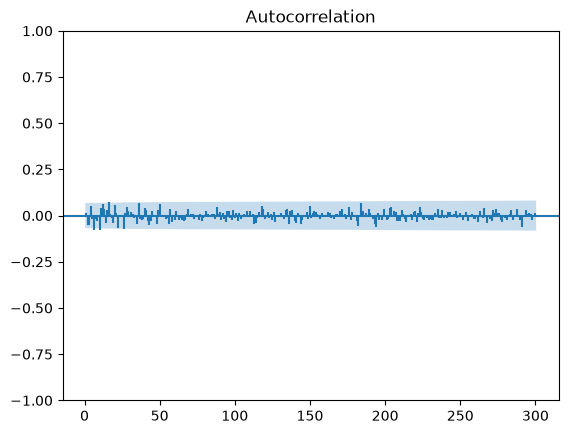

In [876]:

plot_acf(data['returns'],lags=300,zero=False,marker="",alpha=0.01) # 1 % conf int 

plt.show()

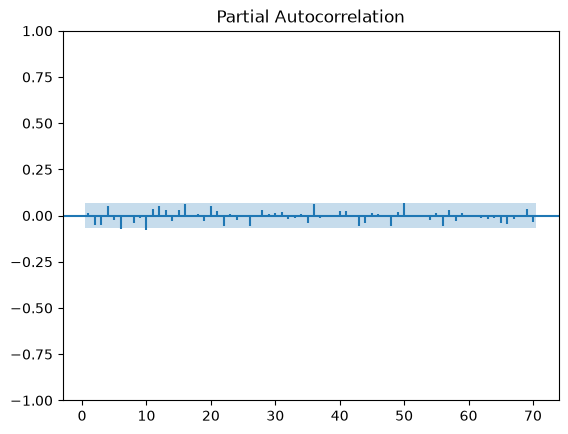

In [884]:
plot_pacf(data['returns'],lags=70,zero=False,marker="",alpha=0.01) # 1 % conf int 

plt.show()


# SARIMA MODEL 

In [878]:
model= ARIMA(data['returns'],order=(1,1,1),seasonal_order=(1,1,1,2)).fit() # SARIMA MODEL


print(model.summary())



                                    SARIMAX Results                                    
Dep. Variable:                         returns   No. Observations:                 1426
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 2)   Log Likelihood               -3358.264
Date:                         Mon, 07 Sep 2026   AIC                           6726.527
Time:                                 21:44:33   BIC                           6752.830
Sample:                                      0   HQIC                          6736.352
                                        - 1426                                         
Covariance Type:                           opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0146      0.021      0.692      0.489      -0.027       0.056
ma.L1         -0.9972      0.004   -239.878      0.000     

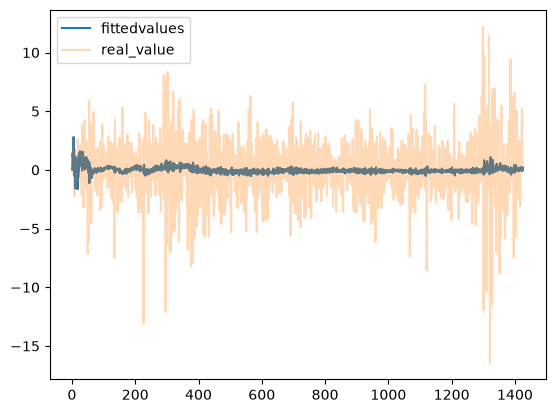

In [879]:
model.fittedvalues.plot(label='fittedvalues')

data['returns'].plot(alpha=0.3,label='real_value')

plt.legend()

plt.show()

# linear regression 

In [880]:
data

,Date,Close,High,Low,Open,Volume,returns,weekdays,months,dif_lag_1
1,2021-01-06,50.630001,50.939999,49.480000,49.820000,509365,1.401964,Wednesday,January,0.700001
2,2021-01-07,50.830002,51.279999,50.389999,50.529999,369292,0.395024,Thursday,January,0.200001
3,2021-01-08,52.240002,52.750000,50.810001,50.930000,499416,2.773952,Friday,January,1.410000
4,2021-01-11,52.250000,52.700001,51.500000,52.580002,394822,0.019139,Monday,January,0.009998
5,2021-01-12,53.209999,53.450001,52.070000,52.180000,400200,1.837319,Tuesday,January,0.959999
...,...,...,...,...,...,...,...,...,...,...
1422,2026-09-01,90.220001,90.970001,86.129997,86.309998,331106,5.200559,Tuesday,September,4.459999
1423,2026-09-02,91.010002,92.290001,88.970001,90.650002,283450,0.875638,Wednesday,September,0.790001
1424,2026-09-03,91.300003,93.139999,89.570000,90.699997,324521,0.318647,Thursday,September,0.290001
1425,2026-09-04,91.480003,92.169998,88.720001,91.669998,324521,0.197153,Friday,September,0.180000


In [881]:


model2 = ols("returns ~ Open+Volume+dif_lag_1",data=data).fit()


print(model2.summary())



                            OLS Regression Results                            
Dep. Variable:                returns   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                 1.290e+04
Date:                Mon, 07 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:44:34   Log-Likelihood:                -969.39
No. Observations:                1426   AIC:                             1947.
Df Residuals:                    1422   BIC:                             1968.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0845      0.081     -1.047      0.2

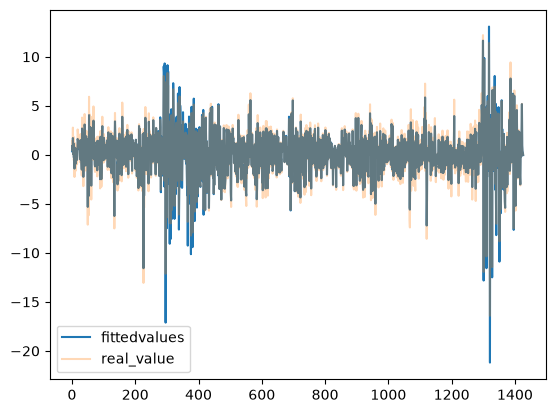

In [882]:
model2.fittedvalues.plot(label='fittedvalues')

data['returns'].plot(alpha=0.3,label='real_value')

plt.legend()

plt.show()

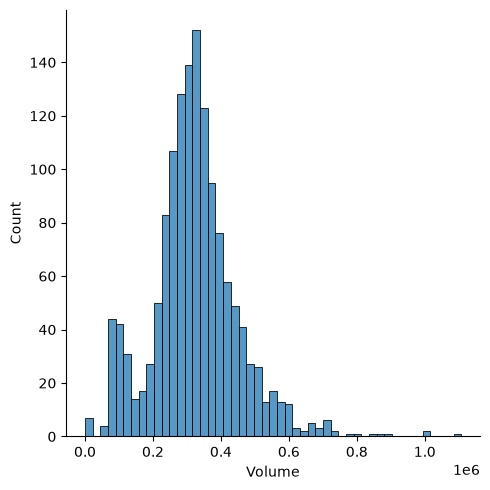

In [ ]:
sns.displot(data,x='Volume')


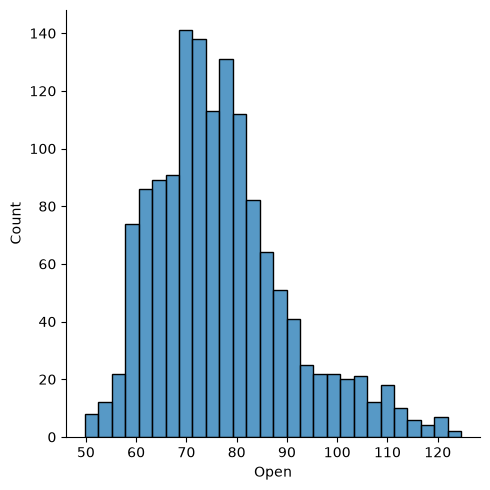

In [ ]:
sns.displot(data,x='Open')

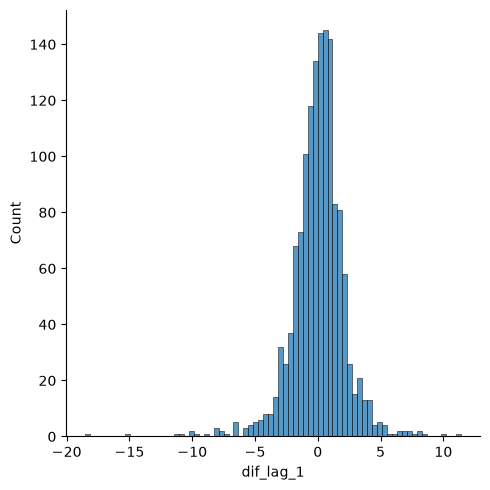

In [ ]:
sns.displot(data,x='dif_lag_1')

In [893]:
data

,Date,Close,High,Low,Open,Volume,returns,weekdays,months,dif_lag_1
1,2021-01-06,50.630001,50.939999,49.480000,49.820000,509365,1.401964,Wednesday,January,0.700001
2,2021-01-07,50.830002,51.279999,50.389999,50.529999,369292,0.395024,Thursday,January,0.200001
3,2021-01-08,52.240002,52.750000,50.810001,50.930000,499416,2.773952,Friday,January,1.410000
4,2021-01-11,52.250000,52.700001,51.500000,52.580002,394822,0.019139,Monday,January,0.009998
5,2021-01-12,53.209999,53.450001,52.070000,52.180000,400200,1.837319,Tuesday,January,0.959999
...,...,...,...,...,...,...,...,...,...,...
1422,2026-09-01,90.220001,90.970001,86.129997,86.309998,331106,5.200559,Tuesday,September,4.459999
1423,2026-09-02,91.010002,92.290001,88.970001,90.650002,283450,0.875638,Wednesday,September,0.790001
1424,2026-09-03,91.300003,93.139999,89.570000,90.699997,324521,0.318647,Thursday,September,0.290001
1425,2026-09-04,91.480003,92.169998,88.720001,91.669998,324521,0.197153,Friday,September,0.180000


In [933]:
import numpy as np
from scipy.stats import t, lognorm

open_ = data["Open"]
open_ = open_[open_ > 0]

volume = data["Volume"]
volume = volume[volume > 0]

df_ret, loc_ret, scale_ret = t.fit(data["returns"])
df_dif, loc_dif, scale_dif = t.fit(data["dif_lag_1"])

shape_open, loc_open, scale_open = lognorm.fit(open_, floc=0)
shape_vol, loc_vol, scale_vol = lognorm.fit(volume, floc=0)

mu_open = np.log(scale_open)
sigma_open = shape_open

mu_vol = np.log(scale_vol)
sigma_vol = shape_vol

<Axes: >

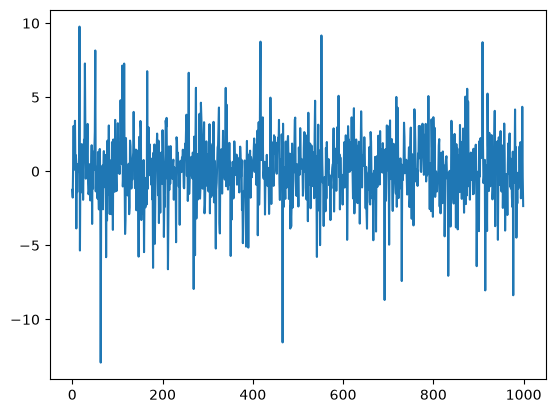

In [ ]:
model2.predict({
    "returns": t.rvs( df=df_ret, loc=loc_ret, scale=scale_ret, size=1000 ),
    "Open": np.random.lognormal( mean=np.log(scale_open), sigma=shape_open, size=1000 ),
    "Volume": np.random.lognormal( mean=np.log(scale_vol), sigma=shape_vol, size=1000 ),
    "dif_lag_1": t.rvs( df=df_dif, loc=loc_dif, scale=scale_dif, size=1000 ) }).plot()

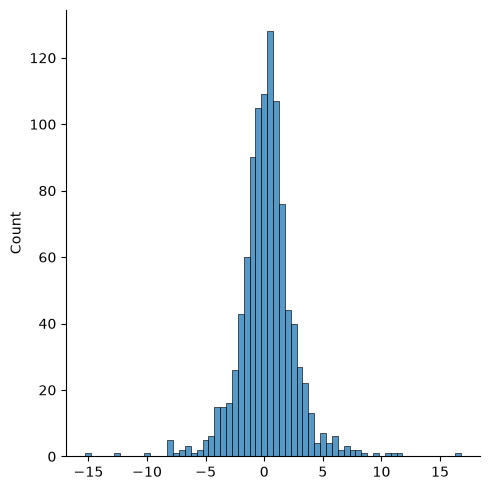

In [940]:
sns.displot(model2.predict(new_data))

# TBD 

In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split, RepeatedKFold,RepeatedStratifiedKFold,TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error,classification_report,f1_score,recall_score,precision_recall_curve,precision_score

